In [1]:
%%capture
!pip install pandas numpy matplotlib

In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import requests

In [3]:
def obter_clima(nome_cidade: str, nome_estado: str, latitude: float, longitude: float, dias= 0):

    """
        Uma função que retorna o clima temperatura e humidade (máxima e mínima)
        esperadas para o próximo dia.
    """

    URL = "https://api.open-meteo.com/v1/forecast"

    params = {
        "latitude": latitude,
        "longitude": longitude,
        "hourly": ["temperature_2m", "relative_humidity_2m"],
        "timezone": "auto"
    }

    response = requests.get(URL, params)
    # print("resposta_obtida")

    # print(response)

    # Transformando a definição em um json.
    data = response.json()

    # print("Data obtida")

    # Criando um DataFrame
    df = pd.DataFrame({
        "data": pd.to_datetime(data['hourly']['time']),
        "temperatura": data['hourly']['temperature_2m'],
        "humidade_relativa": data['hourly']['relative_humidity_2m']
    })


    # Uma coluna apenas com a data dia/mês/ano
    df['data_dia'] = df['data'].dt.date

    previsao_climatica = df.groupby('data_dia').agg({
        "temperatura": ["min", "max", "mean"],
        "humidade_relativa": ["min", "max", "mean"]
    }).reset_index()


    previsao_amanha = previsao_climatica.loc[dias].copy()

    # print(previsao_amanha)

    dia = previsao_amanha['data_dia']
    temp = previsao_amanha['temperatura']
    humid = previsao_amanha['humidade_relativa']

    return {
        "cidade": nome_cidade,
        "estado": nome_estado,
        "dia": dia,
        "temperatura": {"min": temp['min'], "max": temp["max"], "mean": temp["mean"]},
        "humidade": {"min": humid['min'], "max": humid['max'], "mean": humid["mean"]}
    }

In [4]:
def obter_dados_climaticos(cidades_importantes):

    resultados = [
                obter_clima(
                            nome_cidade= dicionario_cidade['nome_cidade'],
                            nome_estado= dicionario_cidade['nome_estado'],
                            latitude= dicionario_cidade['latitude_longitude'][0],
                            longitude= dicionario_cidade['latitude_longitude'][1]
                            ) for dicionario_cidade in cidades_importantes

                ]


    return resultados

In [8]:
# @title
cidades_importantes = [
    # São Paulo
    {
        "nome_cidade": "São Paulo",
        "nome_estado": "São Paulo",
        "latitude_longitude": (-23.5505, -46.6333)
    },
    {
        "nome_cidade": "Campinas",
        "nome_estado": "São Paulo",
        "latitude_longitude": (-22.9099, -47.0626)
    },
    {
        "nome_cidade": "Guarulhos",
        "nome_estado": "São Paulo",
        "latitude_longitude": (-23.4628, -46.5333)
    },

    # Rio de Janeiro
    {
        "nome_cidade": "Rio de Janeiro",
        "nome_estado": "Rio de Janeiro",
        "latitude_longitude": (-22.9068, -43.1729)
    },
    {
        "nome_cidade": "Niterói",
        "nome_estado": "Rio de Janeiro",
        "latitude_longitude": (-22.8833, -43.1036)
    },
    {
        "nome_cidade": "Duque de Caxias",
        "nome_estado": "Rio de Janeiro",
        "latitude_longitude": (-22.7856, -43.3117)
    },

    # Minas Gerais
    {
        "nome_cidade": "Belo Horizonte",
        "nome_estado": "Minas Gerais",
        "latitude_longitude": (-19.9208, -43.9378)
    },
    {
        "nome_cidade": "Uberlândia",
        "nome_estado": "Minas Gerais",
        "latitude_longitude": (-18.9186, -48.2772)
    },
    {
        "nome_cidade": "Juiz de Fora",
        "nome_estado": "Minas Gerais",
        "latitude_longitude": (-21.7642, -43.3496)
    },

    # Goiás
    {
        "nome_cidade": "Goiânia",
        "nome_estado": "Goiás",
        "latitude_longitude": (-16.6869, -49.2648)
    },
    {
        "nome_cidade": "Aparecida de Goiânia",
        "nome_estado": "Goiás",
        "latitude_longitude": (-16.8250, -49.2458)
    },
    {
        "nome_cidade": "Anápolis",
        "nome_estado": "Goiás",
        "latitude_longitude": (-16.3267, -48.9528)
    },

    # Santa Catarina
    {
        "nome_cidade": "Joinville",
        "nome_estado": "Santa Catarina",
        "latitude_longitude": (-26.3044, -48.8456)
    },
    {
        "nome_cidade": "Florianópolis",
        "nome_estado": "Santa Catarina",
        "latitude_longitude": (-27.5954, -48.5480)
    },
    {
        "nome_cidade": "Blumenau",
        "nome_estado": "Santa Catarina",
        "latitude_longitude": (-26.9194, -49.0661)
    }
]

In [9]:
def tratar_dados():

  data_frames = obter_dados_climaticos(cidades_importantes)

  dados_tratados = [(df['cidade'], df['estado'], df['temperatura']['mean'], df['humidade']['mean']) for df in data_frames]

  cidade, estado, temperaturas_media, humidades_medias = zip(*dados_tratados)

  # print(cidade)
  # print(dados_tratados)

  return {
      "nome_cidades": cidade,
      "nome_estados": estado,
      "temperaturas_medias": temperaturas_media,
      "humidades_medias": humidades_medias,
  }

In [10]:
dados_tratados = tratar_dados()

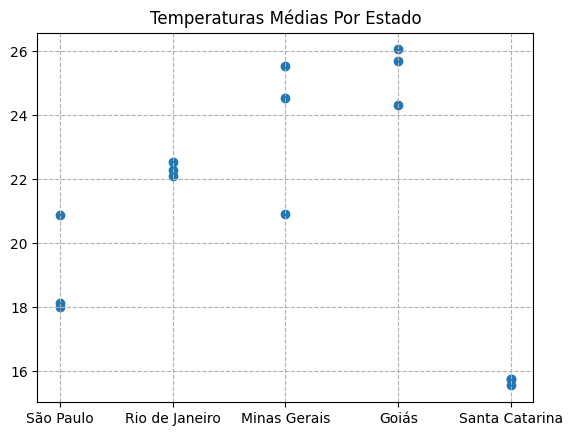

In [12]:
plt.scatter(dados_tratados['nome_estados'], dados_tratados['temperaturas_medias'])

plt.title('Temperaturas Médias Por Estado')

plt.grid(linestyle= '--')
plt.show()

<BarContainer object of 15 artists>

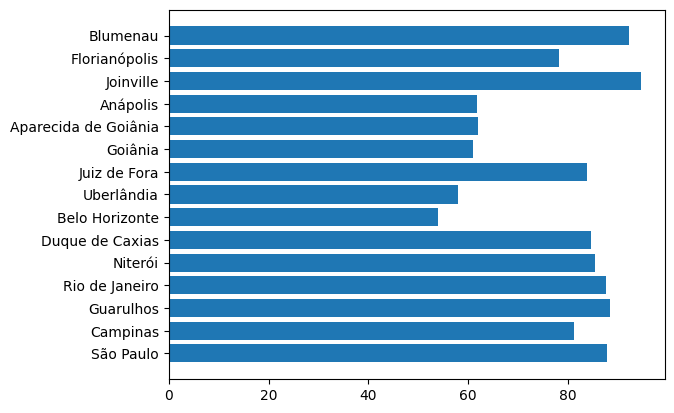

In [15]:
plt.barh(dados_tratados['nome_cidades'], dados_tratados['humidades_medias'])

In [30]:
df.head()

,nome_cidades,nome_estados,temperaturas_medias,humidades_medias
12,Joinville,Santa Catarina,15.745833,94.791667
14,Blumenau,Santa Catarina,15.545833,92.291667
2,Guarulhos,São Paulo,17.991667,88.500000
0,São Paulo,São Paulo,18.120833,87.875000
3,Rio de Janeiro,Rio de Janeiro,22.108333,87.708333


In [17]:
df = pd.DataFrame(dados_tratados)

In [26]:
df = df.sort_values(by= ['humidades_medias'], ascending= False)

In [36]:
df_estados = df.groupby('nome_estados').agg({
    'temperaturas_medias': ['min', 'max', 'mean'],
    'humidades_medias': ['min', 'max', 'mean']
}).reset_index()

In [37]:
df_estados

nome_estados temperaturas_medias                       humidades_medias  \
                                  min        max       mean              min   
0           Goiás           24.320833  26.054167  25.356944        61.041667   
1    Minas Gerais           20.895833  25.541667  23.654167        54.000000   
2  Rio de Janeiro           22.108333  22.525000  22.306944        84.625000   
3  Santa Catarina           15.545833  15.750000  15.680556        78.291667   
4       São Paulo           17.991667  20.883333  18.998611        81.250000   

                         
         max       mean  
0  62.125000  61.694444  
1  84.000000  65.319444  
2  87.708333  85.944444  
3  94.791667  88.458333  
4  88.500000  85.875000

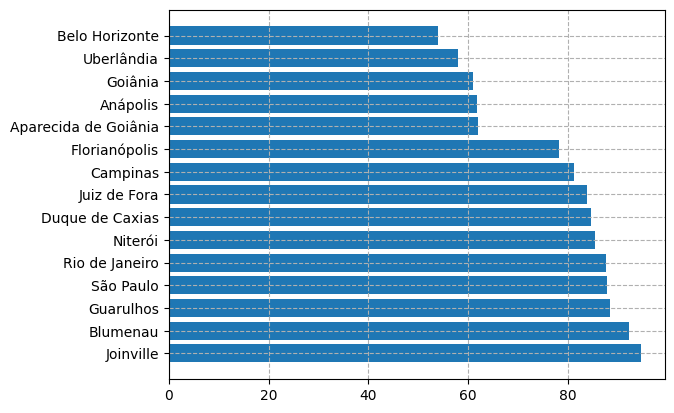

In [29]:
plt.barh(df['nome_cidades'], df['humidades_medias'])

plt.grid(True, linestyle= '--')

In [40]:
df_estados

nome_estados temperaturas_medias                       humidades_medias  \
                                  min        max       mean              min   
0           Goiás           24.320833  26.054167  25.356944        61.041667   
1    Minas Gerais           20.895833  25.541667  23.654167        54.000000   
2  Rio de Janeiro           22.108333  22.525000  22.306944        84.625000   
3  Santa Catarina           15.545833  15.750000  15.680556        78.291667   
4       São Paulo           17.991667  20.883333  18.998611        81.250000   

                         
         max       mean  
0  62.125000  61.694444  
1  84.000000  65.319444  
2  87.708333  85.944444  
3  94.791667  88.458333  
4  88.500000  85.875000

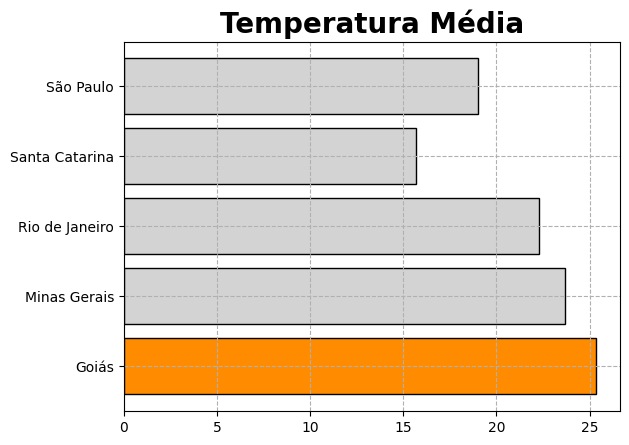

In [64]:
plt.barh(df_estados['nome_estados'],
         df_estados['temperaturas_medias']['mean'],
         color= ['darkorange', 'lightgray', 'lightgray', 'lightgray', 'lightgray'],
         edgecolor= 'black'
         )

plt.grid(True, linestyle= '--')


plt.title("Temperatura Média",
          fontsize= 20,
          weight= 'bold')




plt.show()